# 1- Importing Librarys

In [2]:
import pandas as pd
import numpy as np

#Preperation of the data 
from sklearn import cluster
from sklearn.preprocessing import StandardScaler

#Usupervised Machine Learning
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import DBSCAN

#Visualisation
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

#Imporing Random Rows
import random

#Evaluation metrics
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

# Spotify
import config
from config import CLIENT_ID, CLIENT_SECRET
from IPython.display import IFrame
import spotipy 
import json
from spotipy.oauth2 import SpotifyClientCredentials
import requests
import base64

# 2- Importing The Top 100 Billboard Songs & The Audio Features Dataset

In [3]:
af_df = pd.read_csv(r"C:\Users\ramya\Downloads\audio_features_dataset (1).csv").drop(columns = "Unnamed: 0")
af_df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4


In [4]:
af_df.drop_duplicates(inplace = True)

In [5]:
af_df.dropna(inplace = True)

In [6]:
af_df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4


In [7]:
song_details = af_df[["track_id" ,"artists", "album_name", "track_name"]]
af_df.drop(columns = ["track_id" ,"artists", "album_name", "track_name"], inplace = True)

In [8]:
song_details

,track_id,artists,album_name,track_name
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On
...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends


In [9]:
af_df

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4
1,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4
2,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4
3,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3
4,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5
113996,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4
113997,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4
113998,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4


In [11]:
top_100 = pd.read_csv(r"C:\Users\ramya\Downloads\top_100.csv")
top_100

,Unnamed: 0,artist,song
0,0,Kendrick Lamar & SZA,Luther
1,1,Lady Gaga & Bruno Mars,Die With A Smile
2,2,Kendrick Lamar,Not Like Us
3,3,Kendrick Lamar Featuring Lefty Gunplay,TV Off
4,4,Shaboozey,A Bar Song (Tipsy)
...,...,...,...
95,95,LISA Featuring Doja Cat & RAYE,Born Again
96,96,Giveon,Twenties
97,97,PARTYNEXTDOOR,Deeper
98,98,Bailey Zimmerman,Holy Smokes


In [36]:
af_df_2 = pd.read_csv(r"C:\Users\ramya\Downloads\audio_features_dataset_curated.csv").drop(columns  = "Unnamed: 0")
af_df_2

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5
42996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4
42997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4
42998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4


In [38]:
af_df_2.drop_duplicates(inplace= True)
af_df_2.reset_index(inplace = True, drop = True)
af_df_2

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34718,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5
34719,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4
34720,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4
34721,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4


In [39]:
song_details_2 = af_df_2[["track_id" ,"artists", "album_name", "track_name"]]
af_df_2.drop(columns = ["track_id" ,"artists", "album_name", "track_name"], inplace = True)

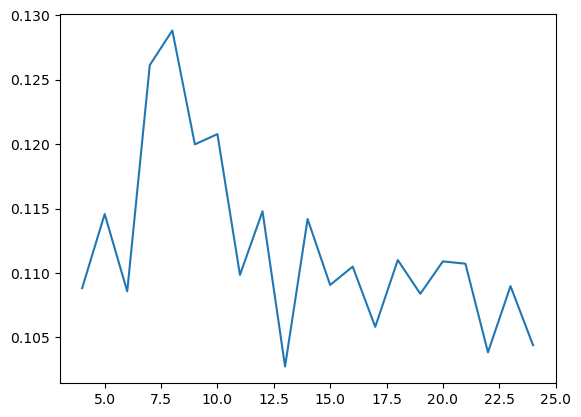

In [44]:
scaler = StandardScaler()
x_std = scaler.fit_transform(af_df_2)



cluster_range = range(4,25)
sil_score_list = []
for i in cluster_range:  
    # Apply KMeans clustering
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(x_std)

    # Compute the Silhouette Score
    sil_score = silhouette_score(x_std, labels)
    #print(f"Silhouette Score: {sil_score}")
    sil_score_list.append(sil_score)
    
xpoints = np.array(cluster_range)
ypoints = np.array(sil_score_list)

plt.plot(xpoints, ypoints)
plt.show()

In [45]:
sil_score_list

[0.10882475683978161,
 0.1145766167479359,
 0.10857054996926561,
 0.12613316592196874,
 0.12882067087842408,
 0.11998389657487447,
 0.12077760763496236,
 0.10984877625254694,
 0.11478951340593255,
 0.10274498260166337,
 0.11418910841389908,
 0.10906955751171184,
 0.11049577112651476,
 0.10581864096545981,
 0.11100533675142636,
 0.10838689594999722,
 0.1108993605160218,
 0.11072081090838427,
 0.10384274382145069,
 0.10898011670361457,
 0.10439803546865989]

In [46]:
my_df = pd.read_csv("C:\\Users\\ramya\\OneDrive\\Documents\\GitHub\\Song--Recommender\\df_final.csv", index_col = [0])
my_df

,id,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,KMeans_Cluster
0,7iL6o9tox1zgHpKUfh9vuC,0.918284,0.713921,0.545455,0.877186,0.0,0.399128,0.256023,0.000000,0.071443,0.789634,0.427110,0.104262,0.8,4
1,4nva9EpKntUTs6CRSGBCn9,0.499489,0.692842,0.090909,0.784674,1.0,0.447110,0.032328,0.006111,0.317861,0.535569,0.459813,0.128928,0.8,6
2,5D2mYZuzcgjpchVY1pmTPh,0.626149,0.574395,1.000000,0.754254,1.0,0.509269,0.025400,0.000031,0.383451,0.767276,0.593726,0.112982,1.0,8
3,5STdMlrBf6pqWiNE7WqxSi,0.601634,0.828353,1.000000,0.872796,1.0,0.418757,0.014356,0.001518,0.141271,0.392276,0.768258,0.139261,0.8,15
4,6mcu7D7QuABVwUGDwovOEh,0.905005,0.626592,1.000000,0.882472,0.0,0.302072,0.266063,0.000000,0.024218,0.869919,0.445788,0.106024,0.8,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11112,66RwIlYInGwQB4BokNhRnd,0.338100,0.548297,0.363636,0.807967,1.0,0.031189,0.287148,0.000000,0.253280,0.219512,0.641549,0.141358,0.8,6
11113,72NcOvvGdarZaOyKMNHZ1m,0.396323,0.175893,0.636364,0.521606,1.0,0.035442,0.685743,0.000009,0.263370,0.107724,0.590235,0.123568,0.8,3
11114,6wx2cwyutp7cgzyi3EYVnM,0.712972,0.297351,0.818182,0.583603,0.0,0.041330,0.513052,0.008513,0.108981,0.264228,0.557105,0.130876,0.8,16
11115,7FHmQOpMo25rPnZeUmCLEQ,0.317671,0.606517,0.727273,0.747103,1.0,0.076554,0.632530,0.000000,0.992936,0.269309,0.531351,0.234038,0.8,3


In [49]:
my_df.drop(columns = ["id" ,"KMeans_Cluster"], inplace = True)

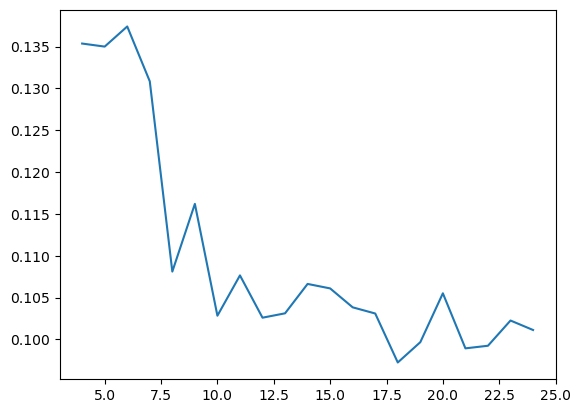

In [50]:
scaler = StandardScaler()
x_std = scaler.fit_transform(my_df)



cluster_range = range(4,25)
sil_score_list_my = []
for i in cluster_range:  
    # Apply KMeans clustering
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(x_std)

    # Compute the Silhouette Score
    sil_score = silhouette_score(x_std, labels)
    #print(f"Silhouette Score: {sil_score}")
    sil_score_list_my.append(sil_score)
    
xpoints = np.array(cluster_range)
ypoints = np.array(sil_score_list_my)

plt.plot(xpoints, ypoints)
plt.show()

In [51]:
sil_score_list

[0.1353725474397987,
 0.13500851027608388,
 0.1374139297266507,
 0.1308545824112635,
 0.10810341169406427,
 0.11619994525634823,
 0.1028270214122093,
 0.10764750029301601,
 0.10259025266573447,
 0.10311231907830735,
 0.10662730104496951,
 0.10609104479329244,
 0.10382902133526899,
 0.10308978622879895,
 0.0972340977914982,
 0.0996635795628808,
 0.10550663894114264,
 0.09892320472858439,
 0.09923466208457474,
 0.10225121459166356,
 0.10111880023431088]

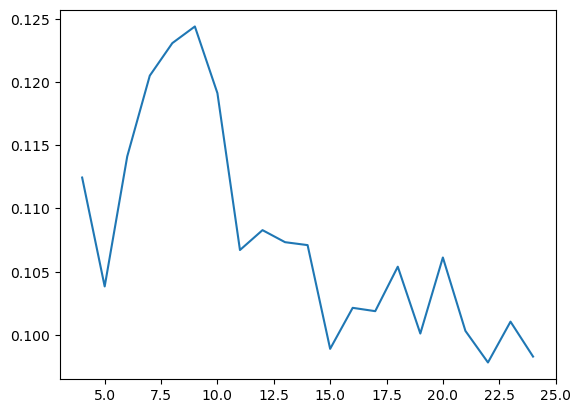

In [53]:
scaler = StandardScaler()
x_std = scaler.fit_transform(af_df)



cluster_range = range(4,25)
sil_score_list_big = []
for i in cluster_range:  
    # Apply KMeans clustering
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(x_std)

    # Compute the Silhouette Score
    sil_score = silhouette_score(x_std, labels)
    #print(f"Silhouette Score: {sil_score}")
    sil_score_list_big.append(sil_score)
    
xpoints = np.array(cluster_range)
ypoints = np.array(sil_score_list_big )

plt.plot(xpoints, ypoints)
plt.show()

# 4- Connecting To The Spotify Api 

In [30]:


def get_spotify_token(CLIENT_ID, CLIENT_SECRET):

    client_credentials = f"{CLIENT_ID}:{ CLIENT_SECRET}"
    client_credentials_b64 = base64.b64encode(client_credentials.encode()).decode()

    headers = {
        "Authorization": f"Basic {client_credentials_b64}",
        "Content-Type": "application/x-www-form-urlencoded"
    }
    data = {
        "grant_type": "client_credentials"
    }

    response = requests.post("https://accounts.spotify.com/api/token", headers=headers, data=data)

    if response.status_code == 200:
        token = response.json().get("access_token")
        return token
    else:
        raise Exception(f"Failed to get token: {response.status_code} {response.text}")

client_id = CLIENT_ID
client_secret = CLIENT_SECRET
token = get_spotify_token(client_id, client_secret)
sp = spotipy.Spotify(auth_manager=SpotifyClientCredentials(client_id= config.CLIENT_ID,
                                                           client_secret= config.CLIENT_SECRET))

In [17]:
def play_song(track_id):
    return IFrame(src="https://open.spotify.com/embed/track/"+track_id,
       width="320",
       height="80",
       frameborder="0",
       allowtransparency="true",
       allow="encrypted-media",
      )

# 5- Creating the recommendation Program 

In [33]:
def recommend_a_genre():
    genre_list = ['trending now']
    print("These are the available genres: (Trending Now, ...., ....., ....., ....., ......, ......)")
    user_prefrence = input("What kind of genre would you like to listen to? ").lower()
    while True:
        if user_prefrence in genre_list:
            break
        else:
            print("These are the available genres: (Trending Now, ...., ....., ....., ....., ......, ......)")
            print('Wrong choice! Please choose from the displayed genres')
            user_prefrence = input("What kind of genre would you like to listen to? ").lower()
    if user_prefrence == "trending now":
        recommended_song = random.choice(top_100['song'])
        artist_of_recommended_song = top_100.loc[top_100["song"] == recommended_song]['artist'].values[0]
        print(f"We can recommend you this song: ({recommended_song}) by ({artist_of_recommended_song})")
        recommended_billboard_song_id = sp.search(q=recommended_song,limit=1,market="GB")["tracks"]["items"][0]["id"]
        return play_song(recommended_billboard_song_id)
    else:
        print("Sorry")

In [34]:
recommend_a_genre()

These are the available genres: (Trending Now, ...., ....., ....., ....., ......, ......)
What kind of genre would you like to listen to? 1
These are the available genres: (Trending Now, ...., ....., ....., ....., ......, ......)
Wrong choice! Please choose from the displayed genres
What kind of genre would you like to listen to? dff
These are the available genres: (Trending Now, ...., ....., ....., ....., ......, ......)
Wrong choice! Please choose from the displayed genres
What kind of genre would you like to listen to? Trending Now
We can recommend you this song: (Somebody Loves Me) by (PARTYNEXTDOOR & Drake)


# 3- Creating The Recommendation Model

In [ ]:
with open('kmeans_19.pkl', 'wb') as file:
    pickle.dump(kmeans_19, file)

with open('kmeans_19.pkl', 'rb') as file:
    kmeans_19 = pickle.load(file)

with open('minmax.pkl', 'wb') as file:
    pickle.dump(minmax, file)   
    
with open('minmax.pkl', 'rb') as file:
    minmax = pickle.load(file)

In [47]:
af_df.dtypes

popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
dtype: object

In [46]:
af_df["explicit"].unique()

array([False,  True])

In [ ]:
for c in range(5,20):
    kmeans = cluster.KMeans(n_clusters=c, random_state=0)
    df["KMeans_Cluster"] = kmeans.fit_predict(df)